<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Py-ART Corrections
---

:::{important} Goal
The goal of this notebook is to showcase ARM open-source software that can be included within your workflows.

Within this notebook, you will learn how to apply corrections such as radar dealiasing to imported radar data
:::



<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/pyart/pyart-corrections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![pyart-correct](../../images/figures/pyart-dealising.png)

## Overview

We have previously covered reading of [X-Band ARM Scanning Preciptiation Radar (XSAPR)](https://armgov.svcs.arm.gov/capabilities/instruments/xsapr) (@sgp-xsapr) data and displaying convective cells associated with the [23 April 2026 Enid, Oklahoma Enhanced Fujita (EF) Scale (EF-4) tornado outbreak](https://en.wikipedia.org/wiki/Tornado_outbreak_sequence_of_April_23%E2%80%9328,_2026). 

Within this notebook, we will cover the [pyart.correct](https://arm-doe.github.io/pyart/API/generated/pyart.correct.html) module for correcting radar moments while in antenna coordinates. Specifically, this notebook will cover:
1. Intro to radar aliasing.
1. Calculation of velocity texture using Py-ART
1. Dealiasing the velocity field within the 23 April 2026 Enid supercells. 

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Py-ART Basics](pyart-basics) | Helpful | Basic features |
| [Weather Radar Basics](https://foundations.projectpythia.org/core/numpy/numpy-basics/) | Helpful | Background Information |
| [Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/matplotlib-basics/) | Helpful | Basic plotting |
| [NumPy Basics](https://foundations.projectpythia.org/core/numpy/numpy-basics.html) | Helpful | Basic arrays |
| [Xarray Basics](https://foundations.projectpythia.org/core/xarray/xarray-intro/) | Helpful | Multi-dimensional arrays |

- **Time to learn**: 15 minutes
---

## An Overview of Aliasing
The radial velocity measured by the radar is mesasured by detecting the phase shift between the transmitted pulse and the pulse recieved by the radar. However, using this methodology, it is only possible to detect phase shifts within ±2π due to the periodicity of the transmitted wave. 

Therefore, for example, a phase shift of 3π would erroneously be detected as a phase shift of −π and give an incorrect value of velocity when retrieved by the radar. This phenomena is called **aliasing**. The maximium unambious velocity that can be detected by the radar before aliasing occurs is called **the Nyquist velocity**.

In the above example, you will see an example of aliasing occurring, where the values of +15 m/s abruptly transition into a region of -15 m/s, with -5 m/s in the middle of the region around 50-100km North of the radar.

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Python ARM Radar Toolkit (Py-ART) within the python environment.
Uncomment the next line prior to importing the python libraries.

Additionally, you will need to upload the XSAPR file we are working with
:::

In [85]:
# Uncomment if running on CoLab
##!pip install arm_pyart>=2.2.0
##!pip install xradar>=0.12.0

## Calculating Velocity Texture with Py-ART

In [86]:
import os
import warnings

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import pyart
from pyart.testing import get_test_data
import xradar as xd

warnings.filterwarnings('ignore')

### Read in the Data

In [87]:
# As in the Py-ART Basics notebook, we begin by loading a XSAPR CF-Radial file for our period of interest. 
# Adjust the base path and file name as needed to point to the location of the data on your system (or Colab)
base_path = "../data/"
file = "sgpxsaprcfrI6.a1.20260423.233233.nc"
dt = xd.io.open_cfradial1_datatree(base_path + file)
radar = pyart.xradar.Xradar(dt)

In [88]:
radar

<xarray.DataTree>
Group: /
│   Dimensions:            (sweep: 18, frequency: 1)
│   Coordinates:
│     * frequency          (frequency) float32 4B 9.671e+09
│       latitude           float32 4B 36.77
│       longitude          float32 4B -97.55
│       altitude           float32 4B 341.0
│   Dimensions without coordinates: sweep
│   Data variables:
│       sweep_fixed_angle  (sweep) float32 72B 0.4999 1.198 1.901 ... 33.0 42.0 50.0
│       sweep_group_name   (sweep) <U10 720B 'sweep_0.0' ... 'sweep_17.0'
│       volume_number      float64 8B 0.0
│   Attributes:
│       Conventions:      ARM-1.2 CF/Radial-1.4 instrument_parameters radar_param...
│       comment:          
│       institution:      U.S. Department of Energy Atmospheric Radiation Measure...
│       instrument_name:  XSAPR-1
│       references:       See Instrument Handbook
│       scan_name:        ppi
│       site_name:        sgpI6
│       source:           IRIS software version: 8.13
│       title:            ARM XSAPR Moments
│       history:          created by user armflowprod on machine prod-slurmnode2....
├── Group: /sweep_0
│       Dimensions:                                          (azimuth: 360, range: 1001)
│       Coordinates:
│         * azimuth                                          (azimuth) float32 1kB 0....
│           time                                             (azimuth) datetime64[ns] 3kB ...
│           elevation                                        (azimuth) float32 1kB ...
│         * range                                            (range) float32 4kB 0.0 ...
│           latitude                                         float32 4B ...
│           longitude                                        float32 4B ...
│           altitude                                         float32 4B ...
│       Data variables: (12/27)
│           time_offset                                      (azimuth) datetime64[ns] 3kB ...
│           attenuation_corrected_differential_reflectivity  (azimuth, range) float32 1MB ...
│           attenuation_corrected_reflectivity_h             (azimuth, range) float32 1MB ...
│           cross_correlation_ratio_hv                       (azimuth, range) float32 1MB ...
│           differential_phase                               (azimuth, range) float32 1MB ...
│           differential_reflectivity                        (azimuth, range) float32 1MB ...
│           ...                                               ...
│           prt                                              (azimuth) float32 1kB ...
│           prt_mode                                         |S22 22B ...
│           radar_measured_transmit_power                    (azimuth) float32 1kB ...
│           sweep_mode                                       <U20 80B 'azimuth_survei...
│           sweep_number                                     float64 8B ...
│           unambiguous_range                                (azimuth) float32 1kB ...
├── Group: /sweep_1
│       Dimensions:                                          (azimuth: 360, range: 1001)
│       Coordinates:
│         * azimuth                                          (azimuth) float32 1kB 0....
│           time                                             (azimuth) datetime64[ns] 3kB ...
│           elevation                                        (azimuth) float32 1kB ...
│         * range                                            (range) float32 4kB 0.0 ...
│           latitude                                         float32 4B ...
│           longitude                                        float32 4B ...
│           altitude                                         float32 4B ...
│       Data variables: (12/27)
│           time_offset                                      (azimuth) datetime64[ns] 3kB ...
│           attenuation_corrected_differential_reflectivity  (azimuth, range) float32 1MB ...
│           attenuation_corrected_reflectivity_h             (azimuth, range) float32 1MB

### Plot a quick-look of reflectivity and velocity
We can start by taking a quick look at the reflectivity and velocity fields. Notice how the velocity field is **rather messy**, indicated by the speckles and high/low values directly next to each other

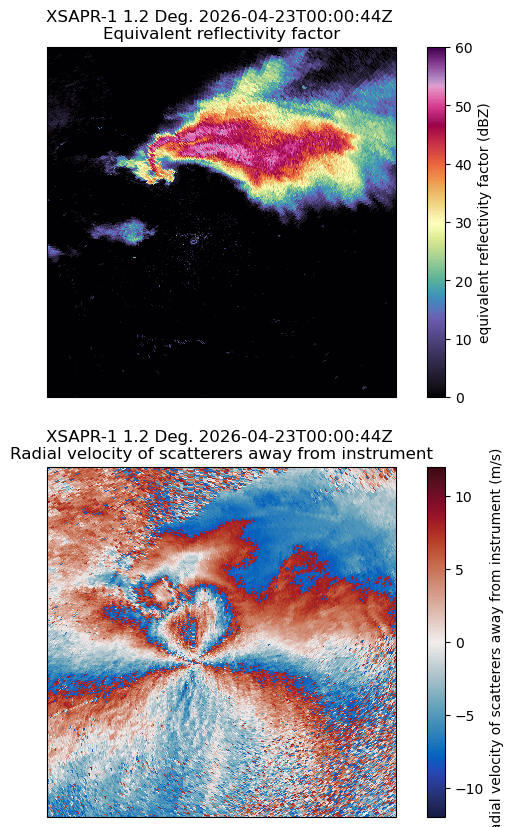

In [89]:
fig = plt.figure(figsize=[8, 10])
ax = plt.subplot(211, projection=ccrs.PlateCarree())
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('reflectivity',
                     ax=ax,
                     sweep=1,
                     resolution='50m',
                     vmin=0,
                     vmax=60, 
                     projection=ccrs.PlateCarree(),    
                     cmap="ChaseSpectral",
                     min_lat=36.3,
                     max_lat=36.9,
                     min_lon=-97.8,
                     max_lon=-97.20)

ax2 = plt.subplot(2,1,2,projection=ccrs.PlateCarree())
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('mean_doppler_velocity',
                     ax=ax2,
                     sweep=1,
                     resolution='50m',
                     vmin=-12,
                     vmax=12, 
                     projection=ccrs.PlateCarree(),
                     cmap='balance',
                     min_lat=36.3,
                     max_lat=36.9,
                     min_lon=-97.8,
                     max_lon=-97.20)
plt.show()

### Calculate Velocity Texture

First, for dealiasing to work efficiently, we need to use a **[GateFilter](https://arm-doe.github.io/pyart/API/generated/pyart.filters.GateFilter.html#pyart.filters.GateFilter)**. 

Notice that, this time, the data shown does not give us a nice gate_id. This is what raw data looks like, and we need to do some preprocessing on the data to remove noise and clutter. 

Thankfully, Py-ART gives us the capability to do this. 

As a simple filter in this example, we will first calculate the velocity texture using Py-ART's [`calculate_velocity_texture`](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.calculate_velocity_texture.html) function. The velocity texture is the standard deviation of velocity surrounding a gate. This will be higher in the presence of noise.

Let's investigate this function first...

In [90]:
pyart.retrieve.calculate_velocity_texture?

Signature:
pyart.retrieve.calculate_velocity_texture(
    radar,
    vel_field=None,
    wind_size=3,
    nyq=None,
    check_nyq_uniform=True,
)
Docstring:
Derive the texture of the velocity field.

Parameters
----------
radar: Radar
    Radar object from which velocity texture field will be made.
vel_field : str, optional
    Name of the velocity field. A value of None will force Py-ART to
    automatically determine the name of the velocity field.
wind_size : int or 2-element tuple, optional
    The size of the window to calculate texture from.
    If an integer, the window is defined to be a square of size wind_size
    by wind_size. If tuple, defines the m x n dimensions of the filter
    window.
nyq : float, optional
    The nyquist velocity of the radar. A value of None will force Py-ART
    to try and determine this automatically.
check_nyquist_uniform : bool, optional
    True to check if the Nyquist velocities are uniform for all rays
    within a sweep, False will skip this 

### Determining the Right Parameters
You'll notice that we need:
- Our radar object
- The name of our velocity field
- The number of gates within our window to use to calculate the texture
- The nyquist velocity

We can retrieve the nyquest velocity from our instrument parameters fortunately - using the following syntax!

### Calculate Velocity Texture and Filter our Data
Now that we have an ide?a of which parameters to pass in, let's calculate velocity texture!

In [91]:
vel_texture = pyart.retrieve.calculate_velocity_texture(radar,
                                                        vel_field='mean_doppler_velocity',
                                                        nyq=8.525)
vel_texture

{'units': 'meters_per_second',
 'standard_name': 'texture_of_radial_velocity_of_scatters_away_from_instrument',
 'long_name': 'Doppler velocity texture',
 'coordinates': 'elevation azimuth range',
 'data': array([[4.14583856, 4.20702349, 4.20702349, ..., 3.97871742, 3.89128569,
         3.69138473],
        [4.14583856, 4.20702349, 4.24720521, ..., 3.97871742, 3.89128569,
         3.50924729],
        [4.97902753, 4.97902753, 5.13052479, ..., 3.8902026 , 3.8902026 ,
         3.50924729],
        ...,
        [2.21806465, 3.24565856, 4.04686669, ...,        nan,        nan,
                nan],
        [3.03031847, 4.85188931, 4.53731102, ...,        nan,        nan,
                nan],
        [4.85188931, 5.06432979, 5.06432979, ...,        nan,        nan,
                nan]], shape=(6480, 1001))}

In [92]:
# Mask out NaN values for histogram plotting - replacing with high frequency value that will be scaled out
vel_update = np.where(np.isnan(vel_texture['data']), 20, vel_texture['data'])
vel_texture['data'] = vel_update

The `pyart.retrieve.calculate_velocity_texture` function results in a data dictionary, including the actual data, as well as metadata. We can add this to our `radar` object, by using the `radar.add_field` method, passing the name of our new field (`"texture"`), the data dictionary (`vel_texture`), and a clarification that we want to replace the existing velocity texture field if it already exists in our radar object (`replace_existing=True`)

In [93]:
radar.add_field('texture', vel_texture, replace_existing=True)

#### Plot our Velocity Texture Field

Now that we have our velocity texture field added to our radar object, let's plot it!

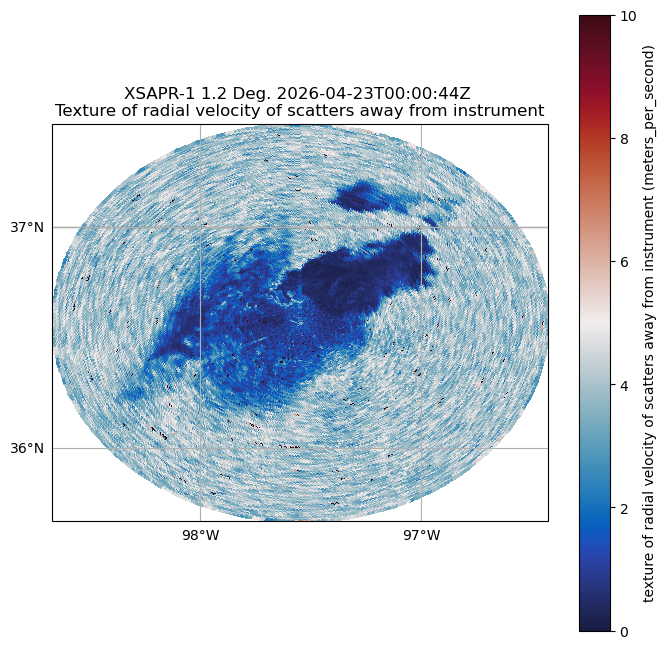

In [94]:
fig = plt.figure(figsize=[8, 8])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('texture',
                     sweep=1,
                     resolution='50m',
                     vmin=0,
                     vmax=10, 
                     projection=ccrs.PlateCarree(),
                     cmap='balance')
plt.show()

#### Determine a Suitable Velocity Texture Threshold

Plot a histogram of velocity texture to get a better idea of what values correspond to hydrometeors and what values of texture correspond to artifacts.

In the below example, a threshold of 2.5 would eliminate most of the peak corresponding to noise around 6 while preserving most of the values in the peak of ~0.5 corresponding to hydrometeors.

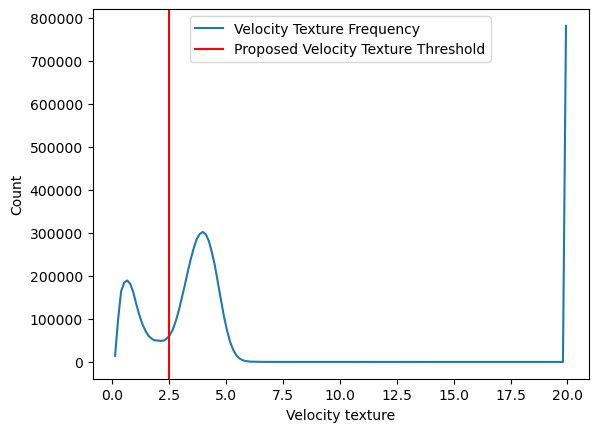

In [95]:
hist, bins = np.histogram(radar.fields['texture']['data'],
                          bins=150)
bins = (bins[1:]+bins[:-1])/2.0

plt.plot(bins,
         hist,
         label='Velocity Texture Frequency')
plt.axvline(2.5,
            color='r',
            label='Proposed Velocity Texture Threshold')

plt.xlabel('Velocity texture')
plt.ylabel('Count')
plt.legend()

#### Setup a Gatefilter Object and Apply our Threshold

Now we can set up our GateFilter ([`pyart.filters.GateFilter`](https://arm-doe.github.io/pyart/API/generated/pyart.filters.GateFilter.html#pyart.filters.GateFilter)), which allows us to easily apply masks and filters to our radar object.

In [96]:
gatefilter = pyart.filters.GateFilter(radar)
gatefilter

We discovered that a velocity texture threshold of **only including values below 3** would be suitable for this dataset, we use the `.exclude_above` method, specifying we want to exclude `texture` values above 3.

In [97]:
gatefilter.exclude_above('texture', 2.5)

#### Plot our Filtered Data

Now that we have created a gatefilter, filtering our data using the velocity texture, let's plot our data!

We need to pass our gatefilter to the `plot_ppi_map` to apply it to our plot.

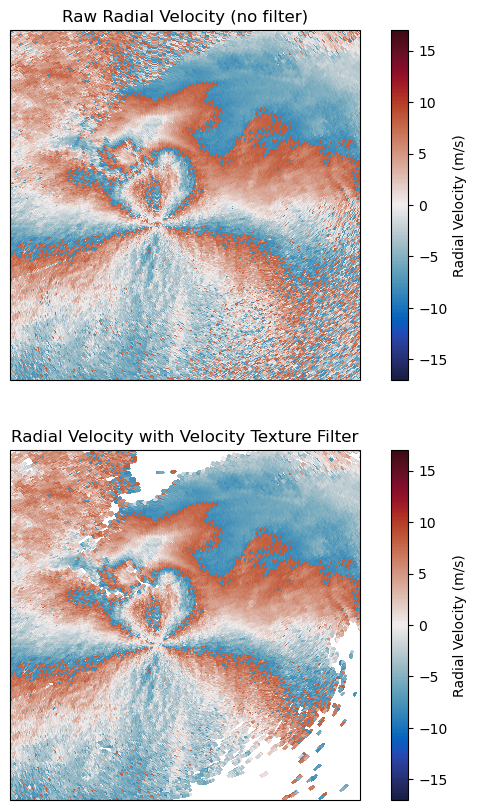

In [98]:
# Plot our Unfiltered Data
fig = plt.figure(figsize=[8, 10])
ax = plt.subplot(211, projection=ccrs.PlateCarree())
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('mean_doppler_velocity',
                     title='Raw Radial Velocity (no filter)',
                     ax=ax,
                     sweep=1,
                     resolution='50m',
                     vmin=-17,
                     vmax=17,
                     projection=ccrs.PlateCarree(),
                     colorbar_label='Radial Velocity (m/s)',
                     cmap='balance',
                     min_lat=36.3,
                     max_lat=36.9,
                     min_lon=-97.8,
                     max_lon=-97.20)

ax2 = plt.subplot(2,1,2,projection=ccrs.PlateCarree())

# Plot our filtered data
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('mean_doppler_velocity',
                     title='Radial Velocity with Velocity Texture Filter',
                     ax=ax2,
                     sweep=1,
                     resolution='50m',
                     vmin=-17,
                     vmax=17, 
                     projection=ccrs.PlateCarree(),
                     colorbar_label='Radial Velocity (m/s)',
                     gatefilter=gatefilter,
                     cmap='balance',
                     min_lat=36.3,
                     max_lat=36.9,
                     min_lon=-97.8,
                     max_lon=-97.20)
plt.show()

### Dealias the Velocity Using the Region-Based Method

At this point, we can use the [`dealias_region_based`](https://arm-doe.github.io/pyart/API/generated/pyart.correct.dealias_region_based.html) to dealias the velocities and then add the new field to the radar!

In [99]:
velocity_dealiased = pyart.correct.dealias_region_based(radar,
                                                        vel_field='mean_doppler_velocity',
                                                        nyquist_vel=8.525,
                                                        centered=True,
                                                        gatefilter=gatefilter)

# Add our data dictionary to the radar object
radar.add_field('corrected_velocity', velocity_dealiased, replace_existing=True)

#### Plot our Cleaned, Dealiased Velocities

Plot the new velocities, which now look much more realistic.

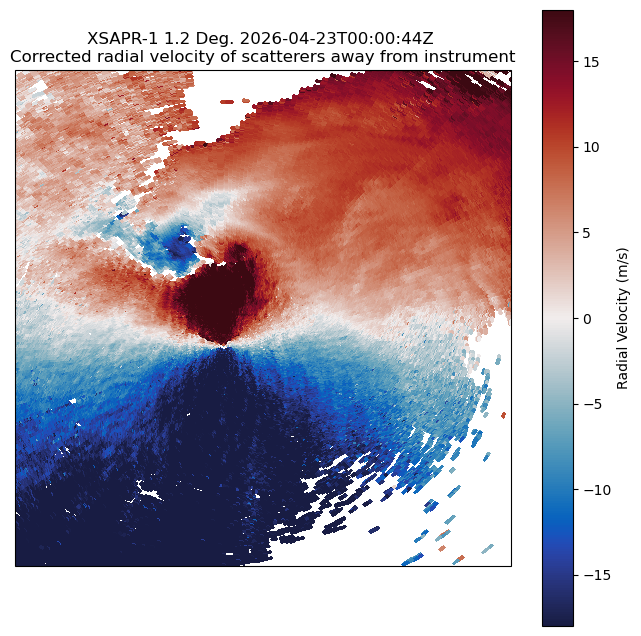

In [100]:
fig = plt.figure(figsize=[8, 8])
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('corrected_velocity',
                     sweep=1,
                     resolution='50m',
                     vmin=-18,
                     vmax=18, 
                     projection=ccrs.PlateCarree(),
                     colorbar_label='Radial Velocity (m/s)',
                     cmap='balance',
                     gatefilter=gatefilter,
                     min_lat=36.3,
                     max_lat=36.9,
                     min_lon=-97.8,
                     max_lon=-97.20)
plt.show()

## Compare our Raw Velocity Field to our Dealiased, Cleaned Velocity Field
As a last comparison, let's compare our raw, uncorrected velocities with our cleaned velocities, after applying the velocity texture threshold and dealiasing algorithm

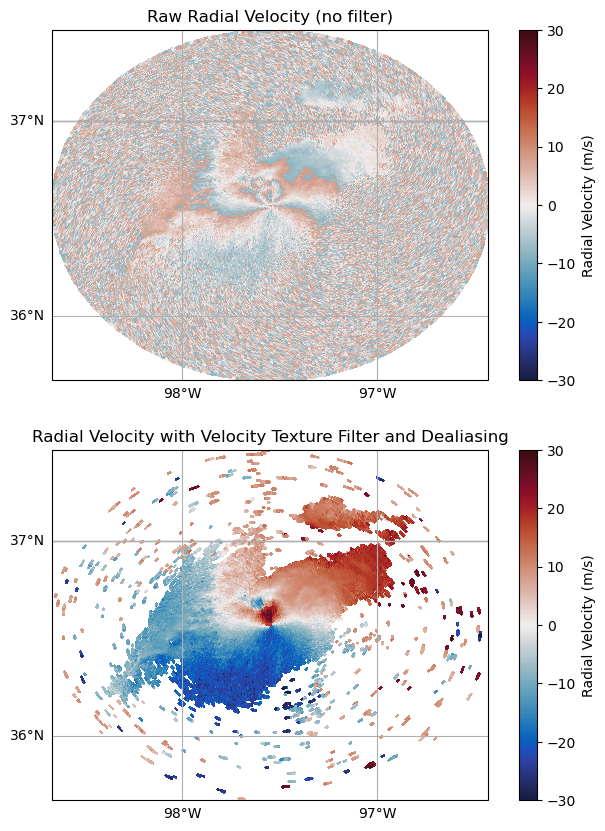

In [101]:
# Plot our Unfiltered Data
fig = plt.figure(figsize=[8, 10])
ax = plt.subplot(211, projection=ccrs.PlateCarree())
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('mean_doppler_velocity',
                     title='Raw Radial Velocity (no filter)',
                     ax=ax,
                     sweep=1,
                     resolution='50m',
                     vmin=-30,
                     vmax=30,
                     projection=ccrs.PlateCarree(),
                     colorbar_label='Radial Velocity (m/s)',
                     cmap='balance')

ax2 = plt.subplot(2,1,2,projection=ccrs.PlateCarree())

# Plot our filtered, dealiased data
display = pyart.graph.RadarMapDisplay(radar)
display.plot_ppi_map('corrected_velocity',
                     title='Radial Velocity with Velocity Texture Filter and Dealiasing',
                     ax=ax2,
                     sweep=1,
                     resolution='50m',
                     vmin=-30,
                     vmax=30, 
                     projection=ccrs.PlateCarree(),
                     gatefilter=gatefilter,
                     colorbar_label='Radial Velocity (m/s)',
                     cmap='balance')
plt.show()

---
:::{admonition} Exercises for Students

We've explored applying corrections to the radar data to clear clutter around the supercell structure

Can you use the gatefilter to explore additional fields within the radar object?
:::

---

## What's Next
In the next notebook, we walk through retrieval development and advanced visualization methods!